In [16]:
import numpy as np
import pandas as pd
import metpy.calc as mpcalc
from metpy.units import units
import  matplotlib.pyplot as plt

In [6]:
qc_fpath = "/home/aoi/research/bsod/sample/data/qc_data/1101322_qc.csv"
df = pd.read_csv(qc_fpath,index_col=0)
df.head()

,TimeUTC,DCnt,RE,FCnt,rcvFREQ,WM,WD,WS,Height,Xdistanc,Ydistanc,HDP,PDP,GeodetLat,GeodetLon,V,FE,FRT,FTI,FVH,FVL,FSP1,FSP2,FSP3,FSP4,N,Prs,Tmp,Hum
0,2024-06-18 01:30:04,0,4,1416,401.90347,1,0.0,0.00,2.0,0.0,0.0,1.0,1.6,34.07084,136.21506,0,0,360.39,0.0,327.71,350.09,0.0,2.05,221.75,0.0,9,1005.0,25.0,50.0
1,2024-06-18 01:30:05,2,4,1418,401.90347,1,180.0,0.00,-0.9,0.0,0.0,1.0,1.6,34.07085,136.21509,0,0,360.39,0.0,327.76,350.04,0.0,1.85,0.00,0.0,9,1005.3,19.2,87.8
2,2024-06-18 01:30:06,4,4,1420,401.90347,1,180.0,0.00,-2.1,0.0,0.0,1.0,1.6,34.07086,136.21512,0,0,360.39,0.0,327.76,350.04,0.0,2.05,221.82,0.0,9,1005.5,18.9,88.0
3,2024-06-18 01:30:07,6,4,1422,401.90347,1,180.0,0.00,-0.8,3.7,0.0,1.0,1.6,34.07085,136.21513,0,0,360.39,0.0,327.75,349.97,0.0,1.85,0.00,0.0,9,1005.3,18.9,88.2
4,2024-06-18 01:30:08,8,4,1424,401.90347,1,0.7,1.18,3.7,3.7,0.0,1.0,1.6,34.07085,136.21513,0,0,360.39,0.0,327.75,349.97,0.0,2.05,221.93,0.0,9,1004.8,18.8,88.5


In [13]:
z = df["Height"].values*units.meter
var_dict = {
    "RH":("Hum",units("percent")),
}

key = "RH"
var_name,var_unit = var_dict[key]
var = df[var_name].values*var_unit

In [22]:
plot_setting_dict = {
    "RH":{
        "xlabel":"Relative Humidity (%)",
        "xlim":[0,100],
    },
}
z_min = np.nanmin(z).m
z_max = np.nanmax(z).m

In [23]:
z_min,z_max

(np.float64(-2.1), np.float64(4703.2))

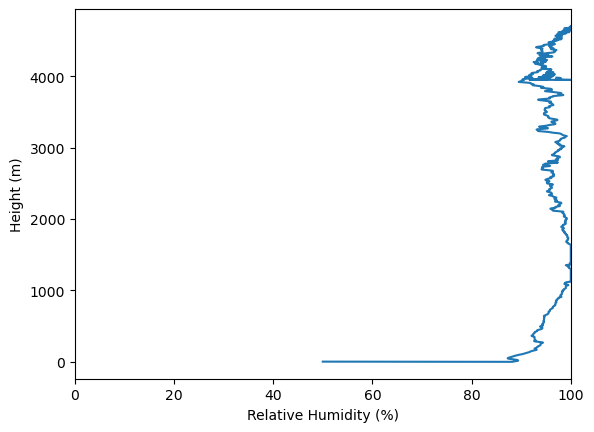

In [21]:
fig,ax = plt.subplots(1,1)
ax.set_xlabel(plot_setting_dict[key]["xlabel"])
ax.set_xlim(plot_setting_dict[key]["xlim"])
ax.set_ylabel("Height (m)")
ax.plot(var,z)
plt.show()